In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import nltk # type: ignore
nltk.download('punkt')
nltk.download('stopwords')



[nltk_data] Downloading package punkt to /home/sumeya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/sumeya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
import pandas as pd

# Load the data
news = pd.read_csv('../data/newsData/raw_analyst_ratings.csv')

# Drop Unnamed column
news = news.drop(columns=['Unnamed: 0'])

# FIXED: Handle mixed date formats
news['date'] = pd.to_datetime(news['date'], format='mixed', utc=True)

# Optional: Convert to timezone-naive for easier analysis
news['date'] = news['date'].dt.tz_convert(None)

print("Date conversion successful!")
print(news['date'].head(10))
print("\nDate Range:", news['date'].min(), "to", news['date'].max())

Date conversion successful!
0   2020-06-05 14:30:54
1   2020-06-03 14:45:20
2   2020-05-26 08:30:07
3   2020-05-22 16:45:06
4   2020-05-22 15:38:59
5   2020-05-22 15:23:25
6   2020-05-22 13:36:20
7   2020-05-22 13:07:04
8   2020-05-22 12:37:59
9   2020-05-22 12:06:17
Name: date, dtype: datetime64[us]

Date Range: 2009-02-14 00:00:00 to 2020-06-11 21:12:35


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# Load and Clean Data
# ======================
news = pd.read_csv('../data/newsData/raw_analyst_ratings.csv')
news = news.drop(columns=['Unnamed: 0'])

# Date conversion (already working)
news['date'] = pd.to_datetime(news['date'], format='mixed', utc=True)
news['date'] = news['date'].dt.tz_convert(None)

# ======================
# Basic Information
# ======================
print(" Dataset Shape:", news.shape)
print("\nColumns:", news.columns.tolist())
print("\nMissing Values:\n", news.isnull().sum())

# Date Range
print("\nDate Range:", news['date'].min(), "→", news['date'].max())

# ======================
# Top Publishers & Stocks
# ======================
print("\n=== Top 10 Publishers ===")
print(news['publisher'].value_counts().head(10))

print("\n=== Top 10 Stocks ===")
print(news['stock'].value_counts().head(10))

# ======================
# Headline Length Analysis
# ======================
news['headline_length'] = news['headline'].str.len()
news['word_count'] = news['headline'].str.split().str.len()

print("\n=== Headline Statistics ===")
print(news[['headline_length', 'word_count']].describe())

✅ Dataset Shape: (1407328, 5)

Columns: ['headline', 'url', 'publisher', 'date', 'stock']

Missing Values:
 headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64

Date Range: 2009-02-14 00:00:00 → 2020-06-11 21:12:35

=== Top 10 Publishers ===
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

=== Top 10 Stocks ===
stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64

=== Headline Statistics ===
       headline_length    word_count
count     1.407328e+06  1.407328e+06
mean      7.312051e+01  1.141671e+01
std       4.073531e+01  6.352997e+00
min       3.000000e+00  1.000000e+00
25%    

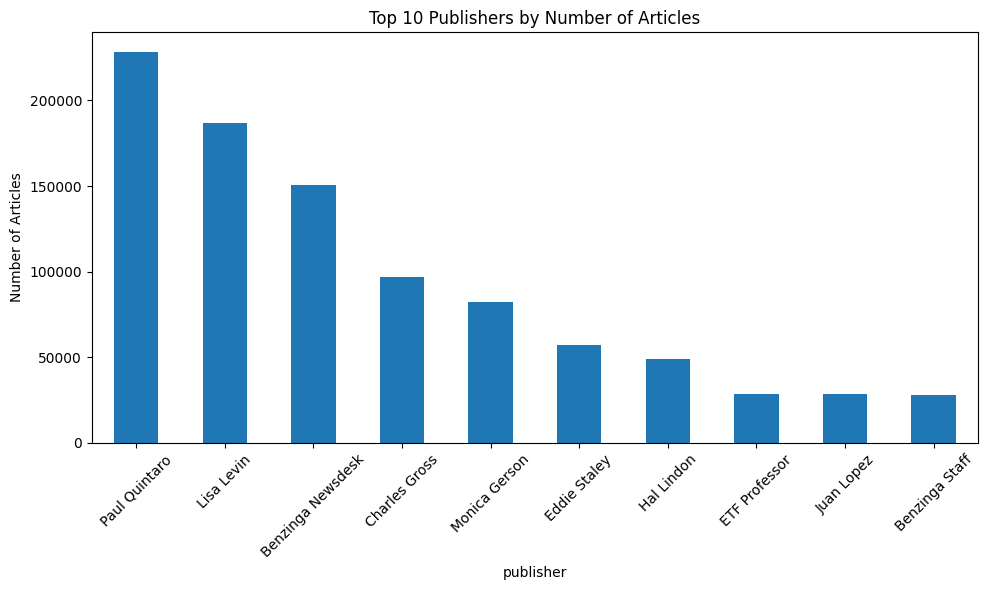

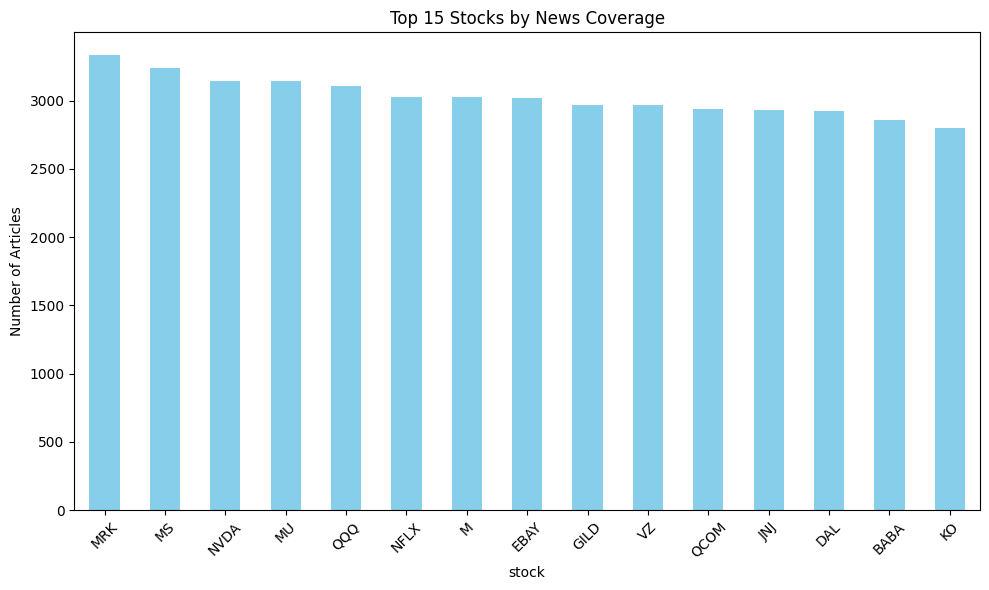

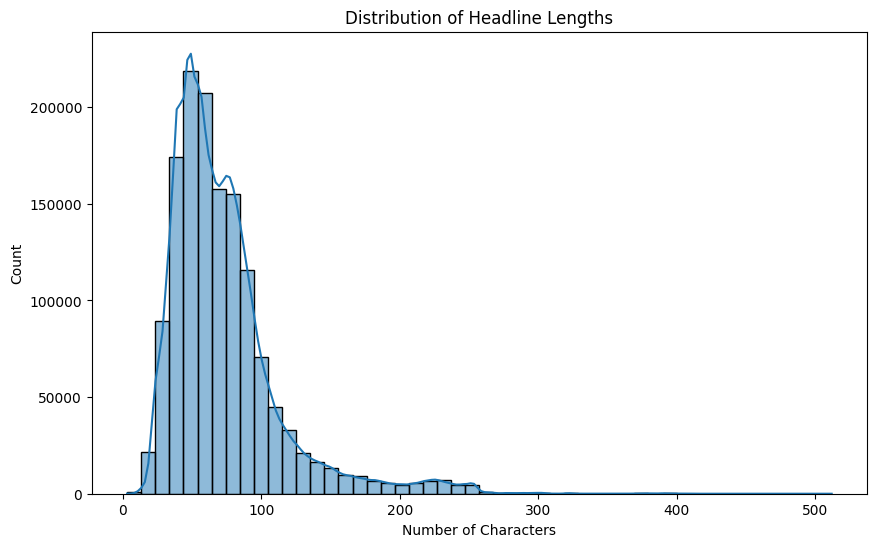

In [8]:
# 1. Top Publishers
plt.figure(figsize=(10, 6))
news['publisher'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Publishers by Number of Articles')
plt.xticks(rotation=45)
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

# 2. Top Stocks
plt.figure(figsize=(10, 6))
news['stock'].value_counts().head(15).plot(kind='bar', color='skyblue')
plt.title('Top 15 Stocks by News Coverage')
plt.xticks(rotation=45)
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

# 3. Headline Length Distribution
plt.figure(figsize=(10, 6))
sns.histplot(news['headline_length'], bins=50, kde=True) # type: ignore
plt.title('Distribution of Headline Lengths')
plt.xlabel('Number of Characters')
plt.show()
